# ENGSCI 263 Computational Modelling Project

## Background
Aquifers are large volumes of porous rock where freshwater is sourced for drinking and
irrigation. Typically, they are at a higher pressure than the ocean level and water flows
outwards preventing salty ocean water flowing back into the aquifer. They are recharged from
freshwater sources.

## Problem
It has been observed that since 2017 the pressure in the aquifer has fallen below ocean surface
levels giving rise to seawater intrusion and increased levels of aquifer salinity. This has been
in part driven by increasing levels of aquifer water extraction by users. The only significant
source of freshwater recharge in this case is from a deep freshwater spring at a depth of 20m
below the surface.

## Stakeholders
Local farmers propose that water extraction should remain at current levels and that the current
drop in pressure is simply seasonal; local businesses growing crops propose that extraction
rates should increase in a trend similar to the last 5 years to allow for increased productivity
and food exports in the region; local iwi wish to consider the environmental impact and want
to halt water extraction until pressure levels return to the average pressure from 2000-2010; the
local council want to see improved economic activity for farming and business but support
local iwi and environmental concerns and want to see a staged recovery of pressure that returns
to 2000 levels.

## Objective
The following project aims to create a computational model of the aquifer, and fit it with the given data. This model will then be used to make predictions for varying extraction rates, and a final recommendation will be given.

In [627]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression

## ODE Model

In [628]:
def ode_model(t, x, q, a, b, c, x0):
    """ Return the derivative dx/dt at time, t, for given parameters.
    Parameters:
    -----------
    t : float
        Independent variable time.
    x : float
        Dependent variable (pressure)
    q : float
        mass injection/ejection rate (aquifer extraction rate)
    a : float
        mass injection strength parameter (aquifer extraction)
    b : float
        recharge strength parameter (aquifer to ocean water)
    c: float
        recharge strength parameter (aquifer to freshwater)
    x0 : float
        pressure of freshwater source relative to ocean level.
    Returns:
    --------
    dxdt : float
        Derivative of dependent variable with respect to independent variable time.
    """
    
    dxdt = -(a * q) - (b * x) - (c * (x - x0))
    return dxdt

## Improved Euler's Method

This function will be used to numerically evaluate our model. Note that although our model can be solved analytically, most differential equations cannot be. Thus it is wise to practice implementing numerical methods. 

In [629]:
def improved_eulers(f, t, xi, dt, n, q, a, b, c, x0):
    x = np.zeros(n)
    x[0] = xi # Initial pressure.
    for i in range(n - 1):
        f0 = f(t, x[i], q[i], a, b, c, x0)
        f1 = f(t + dt, x[i] + dt * f0, q[i], a, b, c, x0)
        x[i + 1] = x[i] + dt * (f0 + f1) / 2
        t += dt
             
    return x

## Visualisation

In [630]:
pressure_df = pd.read_csv('P_acquifer.csv')
pressure_df.head()

,yr,P (MPa)
0,1990,0.42
1,1991,0.27
2,1992,0.24
3,1993,0.18
4,1994,0.22


<Axes: title={'center': 'pressure (MPa) vs time (year)'}, xlabel='yr'>

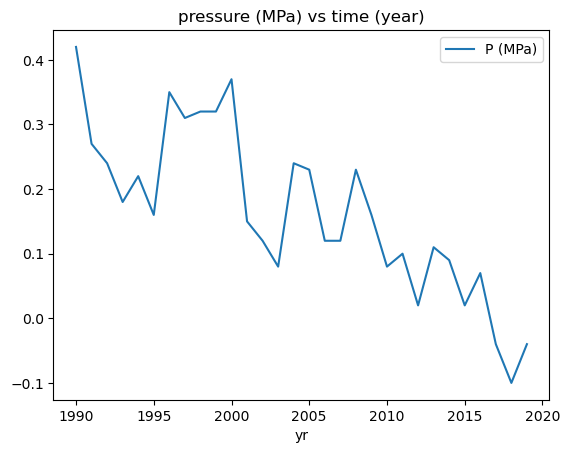

In [631]:
pressure_df.plot(x='yr', y='P (MPa)', title='pressure (MPa) vs time (year)')

The pressure shows a clear downward trend as time increases.

In [632]:
extraction_rate_df = pd.read_csv('q_acquifer.csv')
extraction_rate_df.head()

,yr,q (kg/yr)
0,1960,1.830000e+14
1,1961,2.170000e+14
2,1962,2.720000e+14
3,1963,3.260000e+14
4,1964,3.270000e+14


<Axes: title={'center': 'extraction rate (kg/yr) vs time (yr)'}, xlabel='yr'>

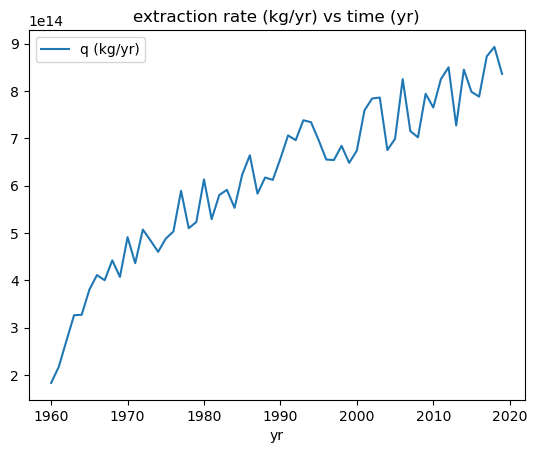

In [633]:
extraction_rate_df.plot(x='yr', y='q (kg/yr)', title='extraction rate (kg/yr) vs time (yr)')

The extraction rate shows a clear increasing trend as time increases. 

## Data Preparation

In [634]:
extraction_rate_pruned_df = extraction_rate_df[extraction_rate_df['yr'] >= 1990].reset_index(drop=True)
extraction_rate_pruned_df.head()

,yr,q (kg/yr)
0,1990,6.570000e+14
1,1991,7.060000e+14
2,1992,6.960000e+14
3,1993,7.380000e+14
4,1994,7.340000e+14


## Fitting to the Data

This function solves our model using the Improved Euler's Method.

In [635]:
def x_curve_fitting(t, n, *args):
    t0 = extraction_rate_pruned_df['yr'].iloc[0] # Initial time.
    xi = pressure_df['P (MPa)'].iloc[0] # Initial pressure.
    q = extraction_rate_pruned_df['q (kg/yr)']
    h = 1 # Step size.

    x = improved_eulers(ode_model, t0, xi, h, n, q, *args)
    return x

Text(0, 0.5, 'Pressure (MPa)')

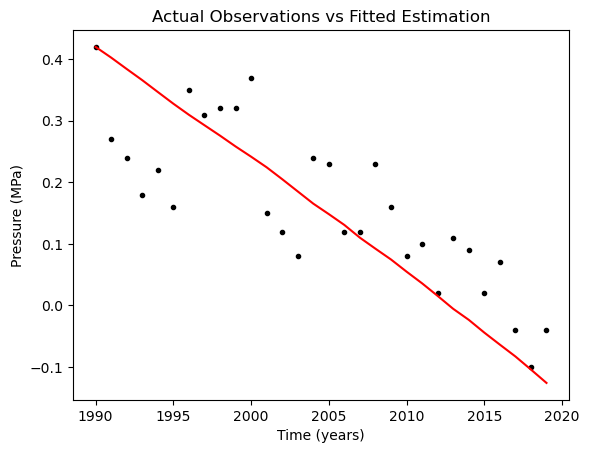

In [644]:
# Values found through research.
a = 1.7836e-14
b = 53 * 0.02502
c = 0.02445 * 27.45 
x0 = 0.2
t = extraction_rate_pruned_df['yr']
n = len(pressure_df)

x = x_curve_fitting(t, n, a, b, c, x0)

plt.plot(t, pressure_df['P (MPa)'], 'k.', label='observation')
plt.plot(t, x, 'r-', label='curve fitting model')
plt.title('Actual Observations vs Fitted Estimation')
plt.xlabel('Time (years)')
plt.ylabel('Pressure (MPa)')

The model appears to be linear, which may indicate underfitting...

### Time Split

We will now proceed with optimising our model parameters by using non-linear least squares.

total misfit:  0.8855194741145502
total misfit:  1.2700743393621752
total misfit:  1.5712048659570679


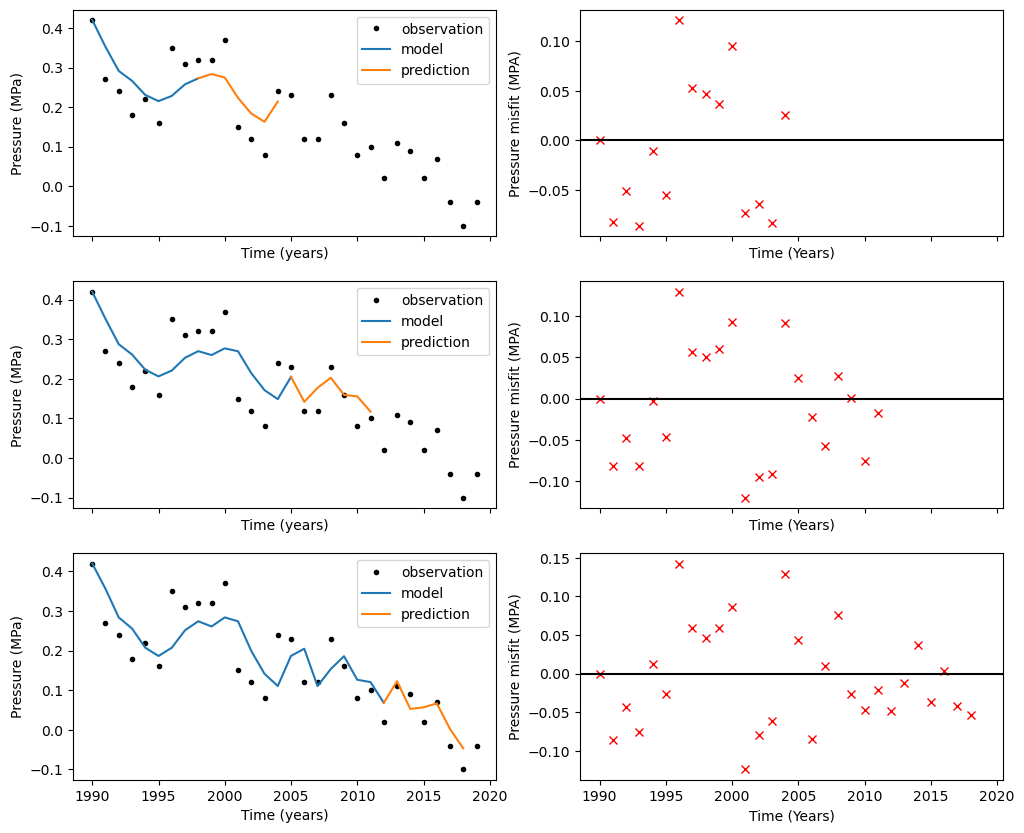

In [645]:
from sklearn.model_selection import TimeSeriesSplit

pars_guess = [a, b, c, x0]

tscv = TimeSeriesSplit(n_splits=3)
fig, ax = plt.subplots(3, 2, sharex=True)
fig.set_figwidth(12)
fig.set_figheight(10)

for i, (train_index, test_index) in enumerate(tscv.split(pressure_df)):
    n = len(train_index)
    pars, pars_cov = curve_fit(lambda t, *args: x_curve_fitting(t, n, *args), pressure_df['yr'].iloc[train_index], pressure_df['P (MPa)'].iloc[train_index], pars_guess)
    x_new = x_curve_fitting(t, n, *pars)
    predicted_x = improved_eulers(ode_model, pressure_df['yr'].iloc[test_index[0]] - 1, x_new[-1], 1, len(test_index), extraction_rate_pruned_df['q (kg/yr)'].iloc[test_index].to_numpy(), *pars)
    
    ax[i][0].plot(pressure_df['yr'], pressure_df['P (MPa)'], 'k.', label='observation')
    ax[i][0].plot(pressure_df['yr'].iloc[train_index], x_new, label='model')
    ax[i][0].plot(pressure_df['yr'].iloc[test_index] - 1, predicted_x, label='prediction')
    ax[i][0].set_xlabel('Time (years)')
    ax[i][0].set_ylabel('Pressure (MPa)')
    ax[i][0].legend()
    
    ax[i][1].plot(pressure_df['yr'].iloc[:test_index[-1]], pressure_df['P (MPa)'].iloc[:test_index[-1]] - np.append(x_new, predicted_x[1:]), 'x', color='r', label='misfit')
    ax[i][1].axhline(y=0, color='k', linestyle='-')
    ax[i][1].set_ylabel('Pressure misfit (MPA)')
    ax[i][1].set_xlabel('Time (Years)')
    
    print('total misfit: ', sum(np.abs(pressure_df['P (MPa)'].iloc[:test_index[-1]] - np.append(x_new, predicted_x[1:]))))

We can deduce from above that our model is able to generalise well to unseen data.

## Optimising fit to data

We will now proceed to fit all our data to our model.

In [639]:
pars_guess = [a, b, c, x0]
n = len(pressure_df)
pars, pars_cov = curve_fit(lambda t, *args: x_curve_fitting(t, n, *args), pressure_df['yr'], pressure_df['P (MPa)'], pars_guess)
pars

array([1.73363689e-15, 7.97371496e-01, 2.02743507e-01, 7.07596634e+00])

total misfit:  1.7365672411195554


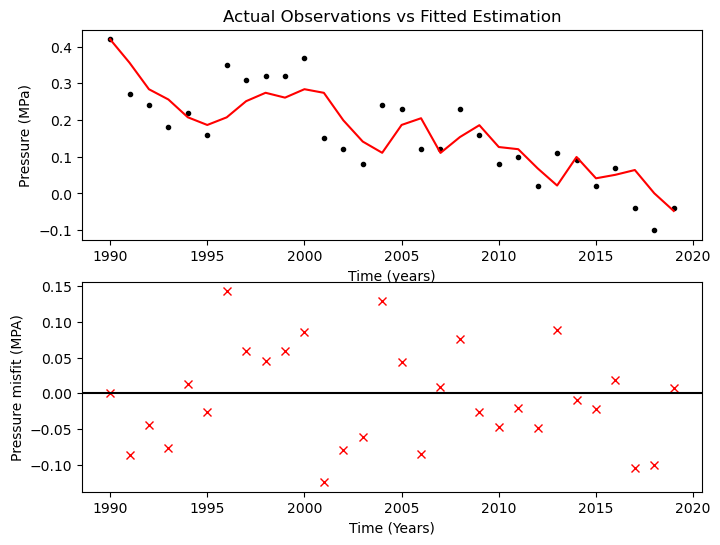

In [647]:
n = len(pressure_df)
x_new = x_curve_fitting(t, n, *pars)
fig, ax = plt.subplots(2)
fig.set_figwidth(8)
fig.set_figheight(6)

ax[0].plot(t, pressure_df['P (MPa)'], 'k.', label='observation')
ax[0].plot(t, x_new, 'r-', label='curve fitting model')
ax[0].set_title('Actual Observations vs Fitted Estimation')
ax[0].set_xlabel('Time (years)')
ax[0].set_ylabel('Pressure (MPa)')

# Plot misfit.
ax[1].plot(t, pressure_df['P (MPa)'] - x_new, 'x', color='r', label='misfit')
ax[1].axhline(y=0, color='k', linestyle='-')
ax[1].set_ylabel('Pressure misfit (MPA)')
ax[1].set_xlabel('Time (Years)')

print('total misfit: ', sum(np.abs(pressure_df['P (MPa)'] - x_new)))


## Predicting

The function below uses the Improved Euler's Method to predict the pressure given the extraction rate.

In [641]:
def ode_prediction(t0, t1, q, *args):
    n = t1 - t0 + 1
    xi = x_curve_fitting(t0, len(pressure_df), *args)[-1]
    predicted_x = improved_eulers(ode_model, t0, xi, 1, n, q, *args)
    return predicted_x

Text(0.5, 0, 'Time (Year)')

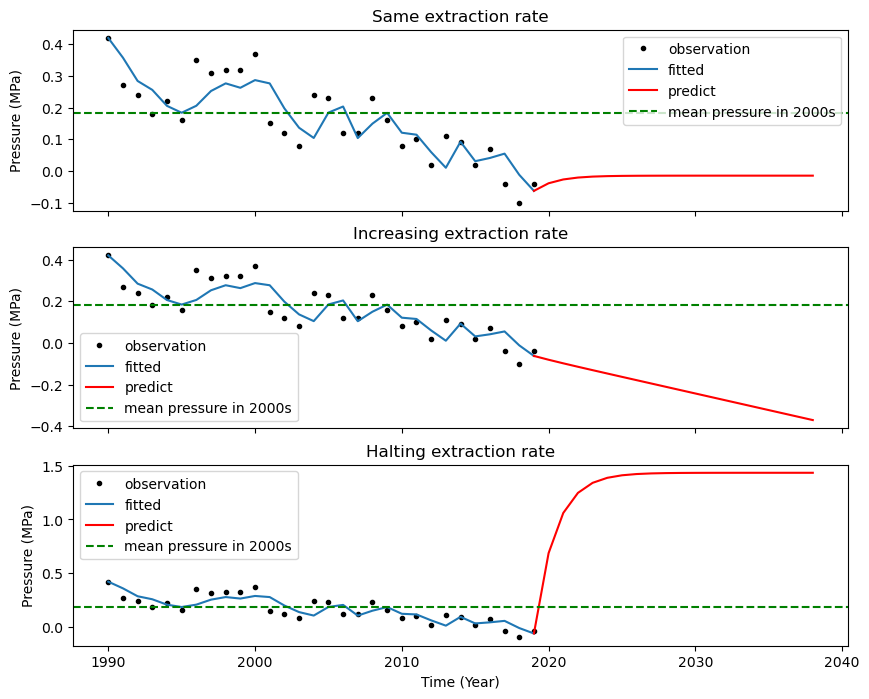

In [642]:
fig, ax = plt.subplots(3, sharex=True)
fig.set_figwidth(10)
fig.set_figheight(8)
t0, t1 = 2019, 2038

mean_pressure_2000 = pressure_df[(pressure_df['yr'] >= 2000) & (pressure_df['yr'] < 2010)].loc[:, 'P (MPa)'].mean()

# Keeping the extraction rate the same.
current_q = np.full((1, t1 - t0 + 1), [extraction_rate_pruned_df['q (kg/yr)'].iloc[-1]])[0]
predicted_x = ode_prediction(t0, t1, current_q, *pars)

# Increasing the extraction rate at the same rate as previous years.
lr = LinearRegression()
lr.fit(extraction_rate_df['yr'].values.reshape(-1, 1), extraction_rate_df['q (kg/yr)'].values)
increasing_q = lr.predict(np.arange(t0, t1 + 1, dtype=int).reshape(-1, 1))
predicted_x1 = ode_prediction(t0, t1, increasing_q, *pars)

# Halt water extraction.
halt_q = np.zeros(t1 - t0 + 1)
predicted_x2 = ode_prediction(t0, t1, halt_q, *pars)

titles = ["Same extraction rate", "Increasing extraction rate", "Halting extraction rate"]
predictions = [predicted_x, predicted_x1, predicted_x2]

for i in range(3):
    ax[i].plot(t, pressure_df['P (MPa)'], 'k.', label='observation')
    ax[i].plot(t, x_new, label='fitted')
    ax[i].plot(np.arange(t0, t1 + 1, dtype=int), predictions[i], 'r-', label='predict')
    ax[i].axhline(mean_pressure_2000, label='mean pressure in 2000s', color="green", linestyle="--")
    ax[i].set_title(titles[i])
    ax[i].set_ylabel('Pressure (MPa)')
    ax[i].legend()

plt.xlabel('Time (Year)')

## Proposed Plan

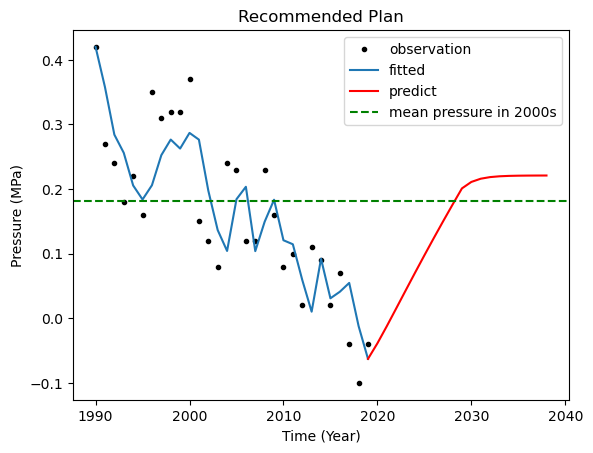

In [643]:
proposed_plan_q = np.zeros(t1 - t0 + 1)
most_recent_extraction_rate = extraction_rate_pruned_df['q (kg/yr)'].iloc[-1]
for i in range(t1 - t0 + 1):
    if i < 10:
        proposed_plan_q[i] = most_recent_extraction_rate * (0.98 ** i)
    else:
        proposed_plan_q[i] = 7e14

predicted_x3 = ode_prediction(t0, t1, proposed_plan_q, *pars)

plt.plot(t, pressure_df['P (MPa)'], 'k.', label='observation')
plt.plot(t, x_new, label='fitted')
plt.plot(np.arange(t0, t1 + 1, dtype=int), predicted_x3, 'r-', label='predict')
plt.axhline(mean_pressure_2000, label='mean pressure in 2000s', color="green", linestyle="--")
plt.title('Recommended Plan')
plt.ylabel('Pressure (MPa)')
plt.xlabel('Time (Year)')
plt.legend()


Our recommendation is to decrease extraction rates by 2% each year starting from 2019 to 2028, then keep the extraction rate constant at 7 x $10^{14}$ kg/year

A yearly decrease in extraction rates of 2% as this would bring pressure to the average levels between 2000 and 2010 within 10 years – meeting the local iwi’s requirements. This will also give time for local businesses and farmers to adjust to smaller extraction rates, and potentially find other ways to make extra revenue.